In [16]:
import sys
from pathlib import Path
import torch
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
import torch.nn.functional as F
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
script_dir = Path.cwd()
sys.path.insert(0, str(script_dir.parent.parent))

from config import ModelConfig, DEFAULT_CONFIG, BATCH_SIZE, NUM_WORKERS
from model import ADModel, create_model, SSLModel, getAttenF
from dataset import FeatureDataset, create_dataloaders

In [17]:
DATASET_NAME = "Pitt"

In [18]:
PROJECT_ROOT = script_dir.parent.parent.parent
TRAIN_CSV = PROJECT_ROOT / f"data/processed/{DATASET_NAME}-xlsr-train.csv"
VAL_CSV = PROJECT_ROOT / f"data/processed/{DATASET_NAME}-xlsr-val.csv"
RAW_AUDIO_DIR = PROJECT_ROOT / f"data/raw/{DATASET_NAME}_merged"
XLSR_FEATURES_DIR = PROJECT_ROOT / f"data/processed/{DATASET_NAME}_xlsr_features"
TRAIN_RATIO = 0.8
SAMPLING_RATE = 16000
FEATURE_DIR_NAME = f"{DATASET_NAME}_xlsr_features"
MODEL_OUTPUT_DIR = PROJECT_ROOT / "models" / f"{DATASET_NAME}_xlsr_multi_seed"
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_COLOR = '#2E86AB'
VAL_COLOR = '#A23B72'

In [19]:
MAX_EPOCHS = 200
LEARNING_RATE = 3e-3
BATCH_SIZE = 32
WEIGHT_DECAY = 1e-2
NUM_WORKERS = 4
RANDOM_SEEDS = [21, 42, 84, 168, 336]

In [20]:
if torch.cuda.is_available():
      device = torch.device('cuda')
elif torch.backends.mps.is_available():
      device = torch.device('mps')
else:
      device = torch.device('cpu')

## Step 1: Create Train/Val Split for Address Dataset


In [21]:
from data_split import create_train_val_split

TRAIN_CSV, VAL_CSV = create_train_val_split(
    raw_audio_dir = RAW_AUDIO_DIR,
    train_csv_path = TRAIN_CSV,
    val_csv_path = VAL_CSV,
    feature_dir_name = FEATURE_DIR_NAME,
    train_ratio=TRAIN_RATIO,
    random_seed = 42,
    dataset_name = DATASET_NAME,
    xlsr=True
)

============= Pitt Train/Val Split Complete! =============
训练集: 440 样本 (Control: 193, Dementia: 247)
验证集: 111 样本 (Control: 49, Dementia: 62)

训练集CSV 路径: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/data/processed/Pitt-xlsr-train.csv
验证集CSV 路径: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/data/processed/Pitt-xlsr-val.csv


## Step 2: Extract XLSR Features


In [22]:
# Import the general-purpose XLSR feature extraction function
from extract_XLSR_feature import extract_xlsr_features_from_csv

# Extract XLSR features using the general function
extract_xlsr_features_from_csv(
    train_csv_path=TRAIN_CSV,
    val_csv_path=VAL_CSV,
    raw_audio_dir=RAW_AUDIO_DIR,
    xlsr_features_dir=XLSR_FEATURES_DIR,
    project_root=PROJECT_ROOT,
    sampling_rate=SAMPLING_RATE,
    device = device
)

Using device: mps
Using original model

============= Extracting XLSR features for Train Set =============
440 Audio Files


Extracting Train Set: 100%|██████████| 440/440 [00:00<00:00, 71589.04it/s]



============= Train Set Extraction Complete! =============
Successfully extracted: 0
Already exists (skipped): 440
Errors: 0
Total: 440

============= Extracting XLSR features for Val Set =============
111 Audio Files


Extracting Val Set: 100%|██████████| 111/111 [00:00<00:00, 58021.90it/s]


============= Val Set Extraction Complete! =============
Successfully extracted: 0
Already exists (skipped): 111
Errors: 0
Total: 111

============= All XLSR Feature Extraction Complete! =============
Training Set:   0 extracted, 440 skipped, 440 total
Validation Set: 0 extracted, 111 skipped, 111 total


## Step 4: Create Data Loaders


In [23]:
# Use XLSR features data loader (pre-extracted features)
train_loader, val_loader = create_dataloaders(
    TRAIN_CSV, VAL_CSV, PROJECT_ROOT, 
    BATCH_SIZE, NUM_WORKERS,
    xlsr=True
)

all_results = {'seeds': [], 'val_accs': [], 'val_losses': []}

=============创建训练集（XLSR 特征）=============
✅ 加载完成: 440 个样本
   Control: 193, Dementia: 247

=============创建验证集（XLSR 特征）=============
✅ 加载完成: 111 个样本
   Control: 49, Dementia: 62



## Step 5: Define Training Function and Model


In [24]:
from visualization import plot_training_curves

class MetricsCallback(pl.Callback):
    def __init__(self):
        self.train_loss = []
        self.train_acc = []
        self.val_loss = []
        self.val_acc = []
        self.epochs = []
    
    def on_train_epoch_end(self, trainer, pl_module):
        self.train_loss.append(trainer.callback_metrics.get('train_loss', 0).item())
        self.train_acc.append(trainer.callback_metrics.get('train_acc', 0).item())
    
    def on_validation_end(self, trainer, pl_module):
        if not trainer.sanity_checking:
            self.epochs.append(trainer.current_epoch)
            self.val_loss.append(trainer.callback_metrics.get('val_loss', 0).item())
            self.val_acc.append(trainer.callback_metrics.get('val_acc', 0).item())

class ADClassifierXLSR(pl.LightningModule):
    def __init__(self):
        super().__init__()
        # Use original ADModel, but configure dim_input=1024 (XLSR feature dimension)
        xlsr_config = ModelConfig(dim_input=1024, dim_hidden=DEFAULT_CONFIG.dim_hidden, dropout=DEFAULT_CONFIG.dropout)
        self.model = ADModel(xlsr_config)
        self.save_hyperparameters()
    def forward(self, x):
        return self.model(x)
    def training_step(self, batch, batch_idx):
        features, labels = batch
        logits = self(features)
        loss = F.cross_entropy(logits, labels)
        acc = (torch.argmax(logits, dim=1) == labels).float().mean()
        self.log('train_loss', loss, on_epoch=True, prog_bar=True)
        self.log('train_acc', acc, on_epoch=True, prog_bar=True)
        return loss
    def validation_step(self, batch, batch_idx):
        features, labels = batch
        logits = self(features)
        loss = F.cross_entropy(logits, labels)
        acc = (torch.argmax(logits, dim=1) == labels).float().mean()
        self.log('val_loss', loss, on_epoch=True, prog_bar=True)
        self.log('val_acc', acc, on_epoch=True, prog_bar=True)
        return loss
    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

def train_and_plot(seed, output_dir):
    """Train single seed and visualize"""
    pl.seed_everything(seed)
    seed_dir = output_dir / f"seed_{seed}"
    seed_dir.mkdir(exist_ok=True)
    
    model = ADClassifierXLSR()
    metrics_cb = MetricsCallback()
    callbacks = [
        ModelCheckpoint(dirpath=seed_dir, filename='best', monitor='val_acc', mode='max', save_top_k=1),
        EarlyStopping(monitor='val_acc', patience=10, mode='max'),
        metrics_cb
    ]
    
    accelerator = 'gpu' if torch.cuda.is_available() else 'cpu'
    trainer_kwargs = {'max_epochs': MAX_EPOCHS, 'callbacks': callbacks, 'accelerator': accelerator,
                     'enable_progress_bar': True, 'enable_model_summary': False}
    if accelerator == 'gpu':
        trainer_kwargs['devices'] = 1
    trainer = pl.Trainer(**trainer_kwargs)
    
    trainer.fit(model, train_loader, val_loader)
   
    # Plot training curves
    plot_training_curves(
        epochs=metrics_cb.epochs,
        train_loss=metrics_cb.train_loss,
        val_loss=metrics_cb.val_loss,
        train_acc=metrics_cb.train_acc,
        val_acc=metrics_cb.val_acc,
        train_color=TRAIN_COLOR,
        val_color=VAL_COLOR,
        title_prefix=f'Seed {seed}'
    )

    best_val_acc_val = max(metrics_cb.val_acc)
    best_val_loss = min(metrics_cb.val_loss)
    print(f" Seed {seed} : Val Acc = {best_val_acc_val*100:.2f}%, Val Loss = {best_val_loss:.4f}")
    
    return seed, best_val_acc_val, best_val_loss


### 1st Random Seed = 21


Seed set to 21
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores


/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/pytorch_lightning/loops/fit_loop.py:310: The number of training batches (14) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 36: 100%|██████████| 14/14 [00:00<00:00, 238.67it/s, v_num=287, train_loss_step=0.173, train_acc_step=0.917, val_loss=0.969, val_acc=0.604, train_loss_epoch=0.244, train_acc_epoch=0.902]


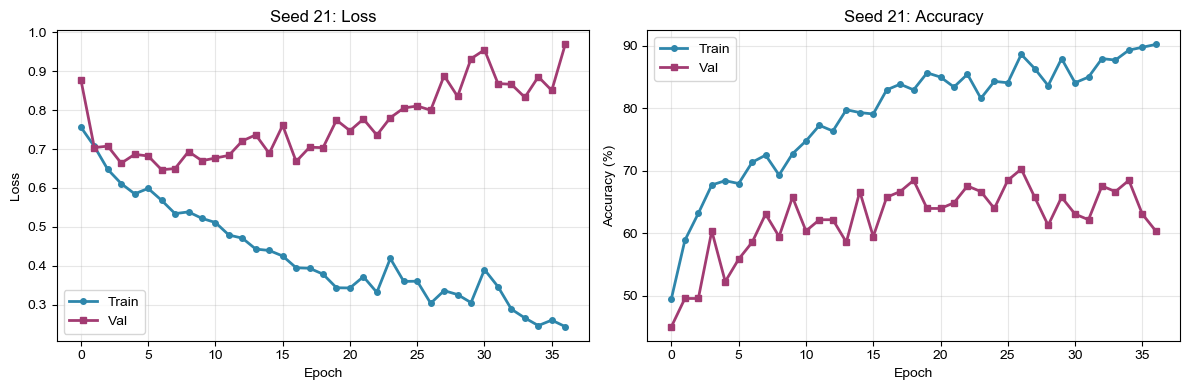

 Seed 21 : Val Acc = 70.27%, Val Loss = 0.6468


In [25]:
# Train Seed 21
seed, val_acc, val_loss = train_and_plot(21, MODEL_OUTPUT_DIR)
all_results['seeds'].append(seed)
all_results['val_accs'].append(val_acc)
all_results['val_losses'].append(val_loss)


### 2nd Random Seed = 42


Seed set to 42
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores


Epoch 11: 100%|██████████| 14/14 [00:00<00:00, 220.06it/s, v_num=288, train_loss_step=0.443, train_acc_step=0.708, val_loss=0.674, val_acc=0.622, train_loss_epoch=0.495, train_acc_epoch=0.768]


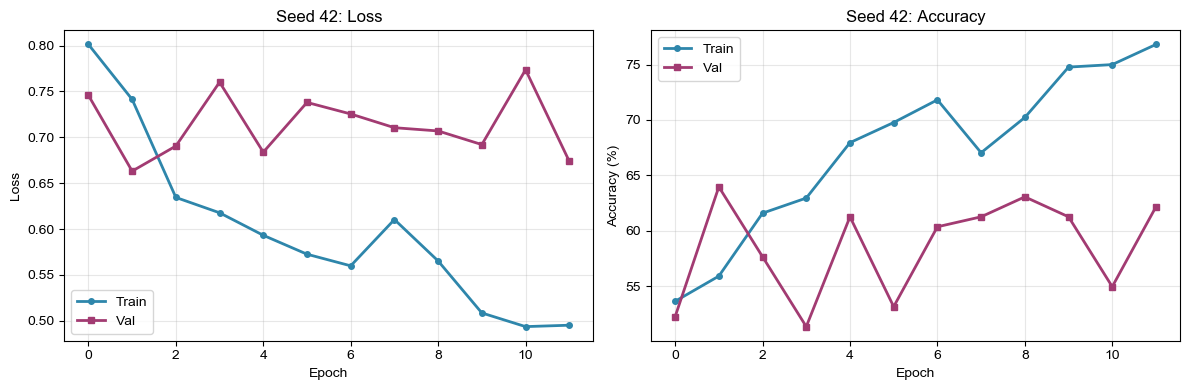

 Seed 42 : Val Acc = 63.96%, Val Loss = 0.6631


In [26]:
# Train Seed 42
seed, val_acc, val_loss = train_and_plot(42, MODEL_OUTPUT_DIR)
all_results['seeds'].append(seed)
all_results['val_accs'].append(val_acc)
all_results['val_losses'].append(val_loss)


### 3rd Random Seed = 84


Seed set to 84
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores


Epoch 27: 100%|██████████| 14/14 [00:00<00:00, 250.57it/s, v_num=289, train_loss_step=0.336, train_acc_step=0.792, val_loss=0.765, val_acc=0.676, train_loss_epoch=0.291, train_acc_epoch=0.864]


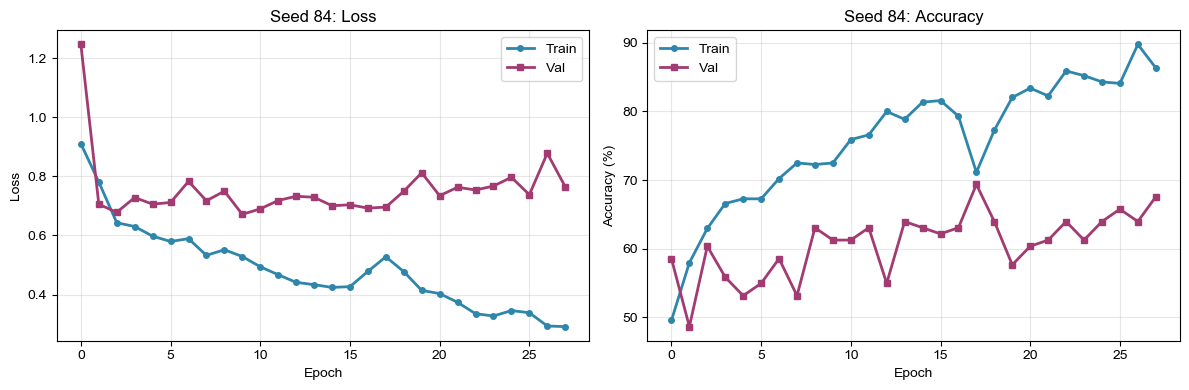

 Seed 84 : Val Acc = 69.37%, Val Loss = 0.6713


In [27]:
# Train Seed 84
seed, val_acc, val_loss = train_and_plot(84, MODEL_OUTPUT_DIR)
all_results['seeds'].append(seed)
all_results['val_accs'].append(val_acc)
all_results['val_losses'].append(val_loss)


### 4th Random Seed = 168


Seed set to 168
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores


Epoch 14: 100%|██████████| 14/14 [00:00<00:00, 242.14it/s, v_num=290, train_loss_step=0.712, train_acc_step=0.625, val_loss=0.681, val_acc=0.577, train_loss_epoch=0.468, train_acc_epoch=0.782]


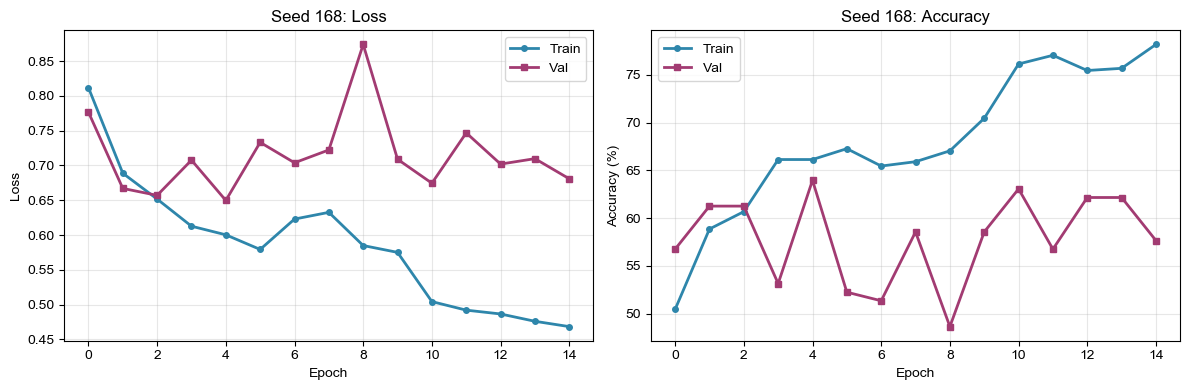

 Seed 168 : Val Acc = 63.96%, Val Loss = 0.6497


In [28]:
# Train Seed 168
seed, val_acc, val_loss = train_and_plot(168, MODEL_OUTPUT_DIR)
all_results['seeds'].append(seed)
all_results['val_accs'].append(val_acc)
all_results['val_losses'].append(val_loss)


### 5th Random Seed = 336


Seed set to 336
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores


Epoch 43: 100%|██████████| 14/14 [00:00<00:00, 220.21it/s, v_num=291, train_loss_step=0.175, train_acc_step=0.917, val_loss=1.020, val_acc=0.685, train_loss_epoch=0.207, train_acc_epoch=0.918]


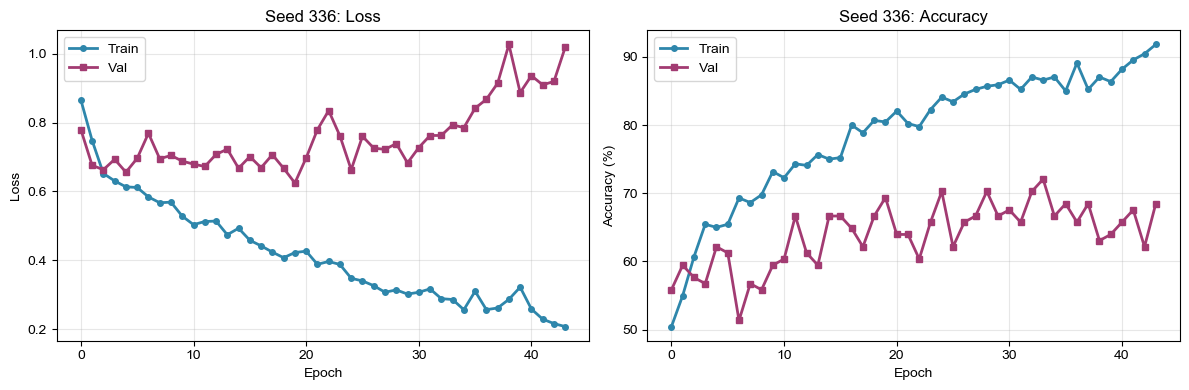

 Seed 336 : Val Acc = 72.07%, Val Loss = 0.6246


In [29]:
# Train Seed 336
seed, val_acc, val_loss = train_and_plot(336, MODEL_OUTPUT_DIR)
all_results['seeds'].append(seed)
all_results['val_accs'].append(val_acc)
all_results['val_losses'].append(val_loss)


In [30]:
# Compare all models
import numpy as np

seeds = all_results['seeds']
val_accs = [acc*100 for acc in all_results['val_accs']]
val_losses = all_results['val_losses']

# Calculate statistics
mean_acc = np.mean(val_accs)
mean_loss = np.mean(val_losses)

print(f"\nMean Validation Accuracy: {mean_acc:.2f}%")
print(f"Mean Validation Loss: {mean_loss:.4f}")
print(f"\nDetailed Results:")
for i, seed in enumerate(seeds):
    print(f"  Seed {seed}: Acc={val_accs[i]:.2f}%, Loss={val_losses[i]:.4f}")



Mean Validation Accuracy: 67.93%
Mean Validation Loss: 0.6511

Detailed Results:
  Seed 21: Acc=70.27%, Loss=0.6468
  Seed 42: Acc=63.96%, Loss=0.6631
  Seed 84: Acc=69.37%, Loss=0.6713
  Seed 168: Acc=63.96%, Loss=0.6497
  Seed 336: Acc=72.07%, Loss=0.6246
